<a href="https://colab.research.google.com/github/levicmm/experiencias-engenharia/blob/main/Trabalho_1_Distribui%C3%A7%C3%A3o_Levi_Lucas_Paulo_Rafael_Yuri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Participantes:

 LEVI CALLEB MAIA MACHADO - 496392

 RAFAEL TAVORA SOARES - 521341

 YURI CAVALCANTE PEREIRA - 536558

 LUCAS ANDRADE DE FREITAS - 563547

 PAULO RICARDO JUCA SANTIAGO - 556325

Link do vídeo de apresentação:https://drive.google.com/file/d/1LryL8CXDSJ0l3Q2v59VwbMlfv6wq90eT/view?usp=sharing

Link do notebook do colab original:https://colab.research.google.com/drive/1hZ8qWkXUVha_CunYDaSIQCBGnrAYkbDG?usp=sharing

Pedimos que o professor caso ache necessário veja o notebook pelo link pois ao gerar o pdf, por algum motivo desconhecido, houve um corte na parte inferior final do relatório

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

In [90]:
# 1. Carregamento e Seleção (Ajustado)
df = pd.read_csv('dataset.csv', index_col=0, parse_dates=True)
energia_total = df.sum() * 0.25 # Esses 0.25 se deve ao fato de que as medições são feitas a cada 15 minutos o que corresponde à 1/4 de hora ou 0.25
perfis_similares = (energia_total - energia_total.median()).abs().sort_values().head(20).index.tolist()
treino, teste = perfis_similares[:10], perfis_similares[10:]

grupo_treino = df[treino] # Criação da tabela com os 10 consumidores de treinamento
grupo_teste = df[teste]   # Criação da tabela com os 10 consumidores de teste

In [91]:
# Cálculo da demanda média mensal para cada um dos 10 consumidores
demanda_media_mensal = grupo_treino.mean()

print("Demanda Média Mensal de cada consumidor (em kW):")
print(demanda_media_mensal)

Demanda Média Mensal de cada consumidor (em kW):
239    109.831273
291    110.108130
31     108.615451
143    108.016782
151    112.309664
45     112.544651
58     106.758089
258    113.406143
282    105.692823
74     105.098248
dtype: float64


##**Demanda Média e Curva de Demanda Média**

A demanda média mensal representa o nível de carregamento constante que o consumidor exigiria se não houvesse variações de uso. Já a Curva de Demanda Média (por intervalo de tempo) é fundamental para identificar o "perfil de carga" ou hábito de consumo. Ela permite que o planejador identifique o horário de ponta (maior consumo médio) e o horário de carga leve, facilitando a previsão de quando a rede será mais exigida de forma sistemática.

Abaixo segue a equação utilizada para calcular o que foi feito:
\begin{equation}
D_{med} = \frac{1}{N} \sum_{i=1}^{N} P_i
\end{equation}
Onde $P_i$ é a potência ativa medida em cada intervalo $i$ e $N$ é o número total de intervalos no mês.

Demanda Média Mensal (kW):
239    109.831273
291    110.108130
31     108.615451
143    108.016782
151    112.309664
45     112.544651
58     106.758089
258    113.406143
282    105.692823
74     105.098248
dtype: float64


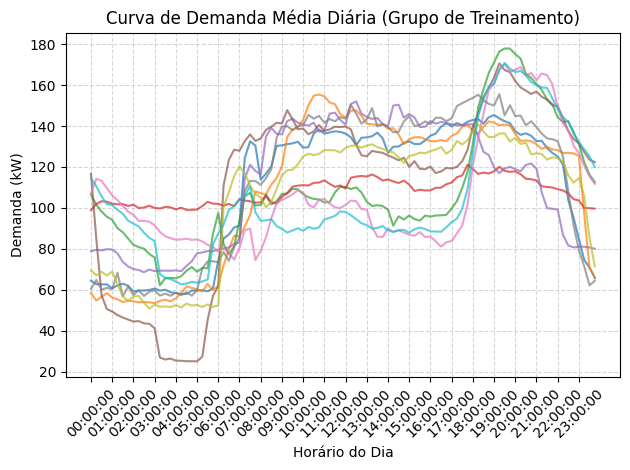

In [92]:
# Cálculo da Demanda Média Mensal
demanda_media_mensal = grupo_treino.mean()
print("Demanda Média Mensal (kW):")
print(demanda_media_mensal)

# Curva de Demanda Média Diária
curva_media_diaria = grupo_treino.groupby(grupo_treino.index.time).mean()

# Plotagem com eixo X limpo (de hora em hora)
plt.plot(curva_media_diaria.index.astype(str), curva_media_diaria, alpha=0.7)
plt.title('Curva de Demanda Média Diária (Grupo de Treinamento)')
plt.xlabel('Horário do Dia')
plt.ylabel('Demanda (kW)')

# Ajuste: Pega todos os horários mas só mostra a etiqueta a cada 4 (1 hora = 4 * 15min)
todos_os_horarios = curva_media_diaria.index.astype(str)
plt.xticks(todos_os_horarios[::4], rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [93]:
# Cálculo da Energia Consumida (kWh) para o Grupo de Treinamento
energia_kwh = grupo_treino.sum() * 0.25

print("Energia Consumida no Mês (kWh):")
print(energia_kwh)

Energia Consumida no Mês (kWh):
239    79078.516881
291    79277.853261
31     78203.125000
143    77772.082879
151    80862.958227
45     81032.148900
58     76865.823817
258    81652.423107
282    76098.832418
74     75670.738328
dtype: float64


##**Energia Consumida (kWh)**

Tecnicamente, a energia é a integral da potência ativa no tempo. No contexto deste projeto, o cálculo da energia acumulada no mês serve como a variável independente para o modelo de regressão linear. Existe uma correlação física entre o volume total de energia utilizada e a magnitude da demanda máxima esperada, o que torna este cálculo o pilar para estimar o comportamento de novos consumidores (grupo de teste).

A energia total acumulada, considerando intervalos de integração de 15 minutos (0,25h), é calculada como:
\begin{equation}
E = \sum_{i=1}^{N} (P_i \times \Delta t) \quad \text{com} \quad \Delta t = 0,25\,h
\end{equation}

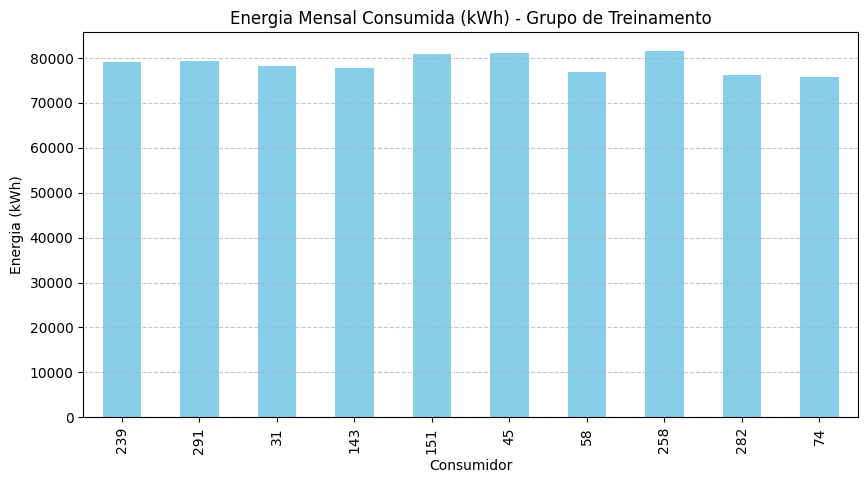

In [94]:
plt.figure(figsize=(10, 5))
energia_kwh.plot(kind='bar', color='skyblue')
plt.title('Energia Mensal Consumida (kWh) - Grupo de Treinamento')
plt.xlabel('Consumidor')
plt.ylabel('Energia (kWh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Demanda Máxima Individual (kW):
239    177.548232
291    187.500000
31     222.039474
143    189.749182
151    190.110827
45     241.962775
58     208.809135
258    179.621451
282    156.428571
74     216.069490
dtype: float64


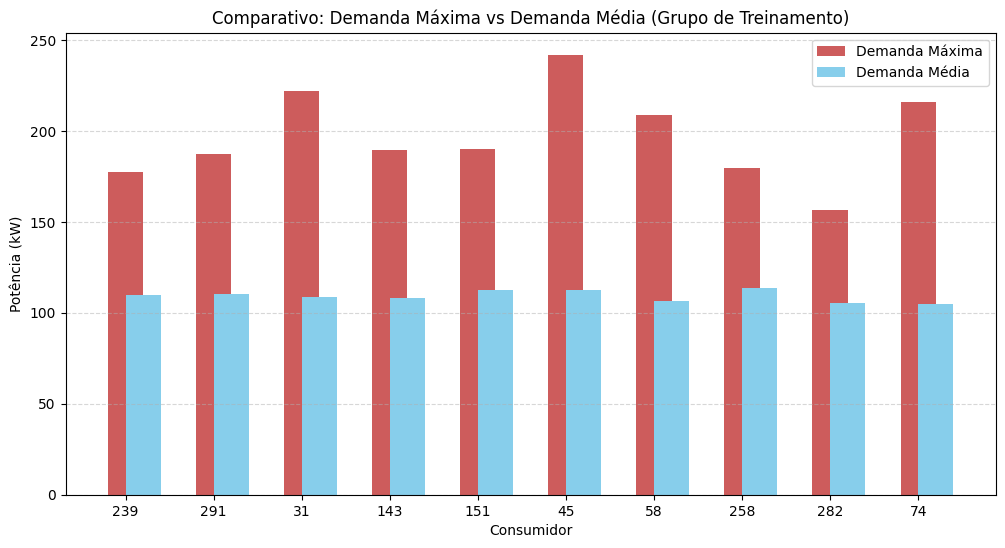

In [95]:
# Cálculo da Demanda Máxima Individual (kW)
# O comando .max() busca o maior valor de cada coluna no DataFrame
demanda_maxima = grupo_treino.max()

print("Demanda Máxima Individual (kW):")
print(demanda_maxima)

# Criando um gráfico comparativo: Demanda Máxima vs Demanda Média
# (Usando a 'demanda_media_mensal' que calculamos no passo anterior)
plt.figure(figsize=(12, 6))
x = range(len(demanda_maxima))

plt.bar(x, demanda_maxima, width=0.4, label='Demanda Máxima', color='indianred', align='center')
plt.bar(x, demanda_media_mensal, width=0.4, label='Demanda Média', color='skyblue', align='edge')

plt.xticks(x, demanda_maxima.index)
plt.title('Comparativo: Demanda Máxima vs Demanda Média (Grupo de Treinamento)')
plt.xlabel('Consumidor')
plt.ylabel('Potência (kW)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Utilizou-se a função de agregação de valor máximo sobre a série histórica mensal de cada consumidor do grupo de treinamento para extrair o maior valor de potência ativa registrado em um intervalo de 15 minutos.

A Demanda Máxima Individual representa o instante de maior solicitação de potência que um único consumidor impõe à rede elétrica durante o mês:
\begin{equation}
D_{max} = \max \{P_1, P_2, \dots, P_N\}
\end{equation}

Fator de Carga de cada consumidor:
239    0.618600
291    0.587243
31     0.489172
143    0.569261
151    0.590759
45     0.465132
58     0.511271
258    0.631362
282    0.675662
74     0.486409
dtype: float64


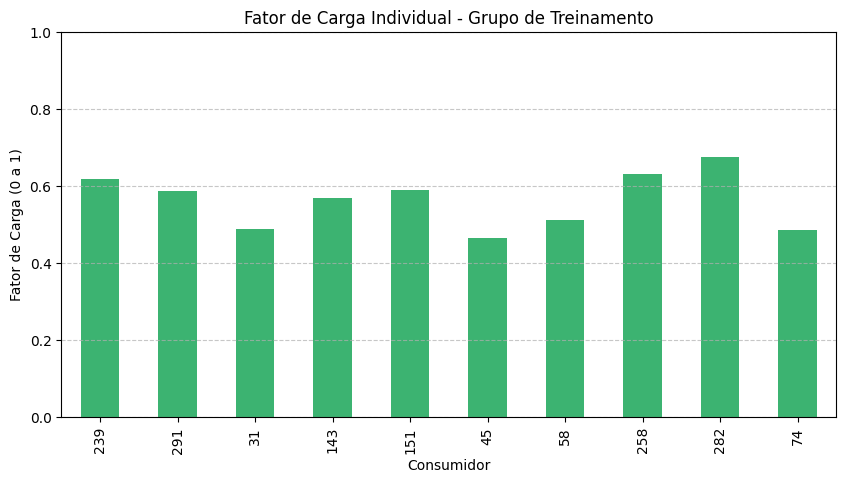

In [96]:
# Cálculo do Fator de Carga (FC)
# FC = Demanda Média / Demanda Máxima
fator_de_carga = demanda_media_mensal / demanda_maxima

print("Fator de Carga de cada consumidor:")
print(fator_de_carga)

plt.figure(figsize=(10, 5))
fator_de_carga.plot(kind='bar', color='mediumseagreen')
plt.title('Fator de Carga Individual - Grupo de Treinamento')
plt.xlabel('Consumidor')
plt.ylabel('Fator de Carga (0 a 1)')
plt.ylim(0, 1) # A escala do FC é sempre entre 0 e 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Realizou-se o cálculo da razão aritmética entre a potência média utilizada e o pico de demanda registrado para cada unidade consumidora do conjunto de dados selecionado. Esse procedimento resultou em um valor adimensional que indica quão próximo o consumo real está da capacidade máxima solicitada ao longo do período mensal de medição.

O índice que mensura a eficiência do uso da demanda em relação ao pico registrado:
\begin{equation}
FC = \frac{D_{med}}{D_{max}}
\end{equation}

Demanda Máxima Diversificada por número de consumidores (n):
    n     D_div_kW
0   1   177.548232
1   2   338.105340
2   3   524.953295
3   4   673.647491
4   5   803.229759
5   6  1019.593774
6   7  1185.988554
7   8  1333.173096
8   9  1467.554964
9  10  1628.249861


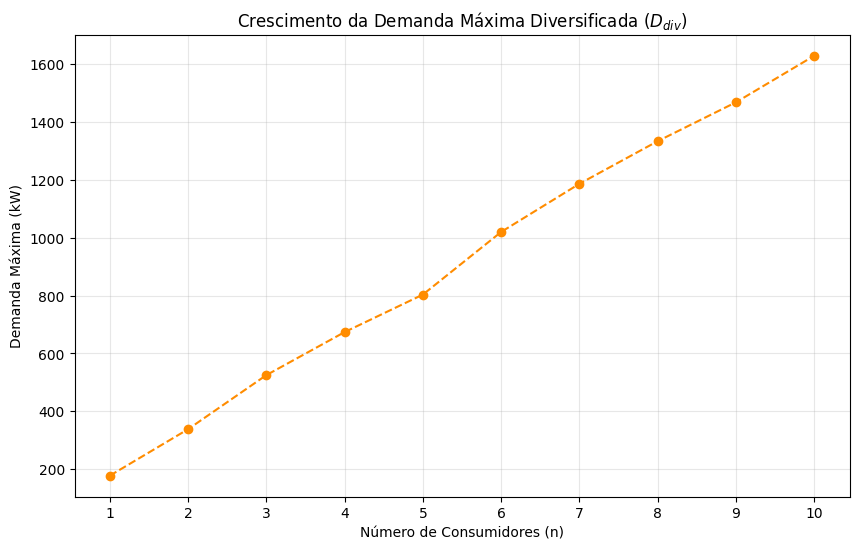

In [97]:
# Cálculo da Demanda Máxima Diversificada Incremental (n=1 até 10)
resultados_diversificada = []
curva_agregada = pd.Series(0, index=grupo_treino.index) # Inicia uma curva "vazia"

# Loop para adicionar um consumidor por vez
for i, consumidor in enumerate(grupo_treino.columns):
    n = i + 1
    # Soma a curva do novo consumidor à curva agregada anterior
    curva_agregada = curva_agregada + grupo_treino[consumidor]

    # A demanda diversificada é o máximo da curva somada
    d_div = curva_agregada.max()

    resultados_diversificada.append({'n': n, 'D_div_kW': d_div})

# Transformando em DataFrame para exibição
df_div = pd.DataFrame(resultados_diversificada)
print("Demanda Máxima Diversificada por número de consumidores (n):")
print(df_div)

# --- Visualização do Crescimento da Demanda ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_div['n'], df_div['D_div_kW'], marker='o', color='darkorange', linestyle='--')
plt.title('Crescimento da Demanda Máxima Diversificada ($D_{div}$)')
plt.xlabel('Número de Consumidores (n)')
plt.ylabel('Demanda Máxima (kW)')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

Foi implementado um processo iterativo onde, a cada passo, um novo perfil de carga foi somado vetorialmente à curva agregada dos consumidores anteriores. Para cada incremento no número de consumidores, identificou-se o valor de pico global da curva resultante, consolidando a progressão da demanda máxima solicitada ao sistema.


Comparativo: Demanda Diversificada vs Não Coincidente:
    n     D_div_kW      D_nc_kW
0   1   177.548232   177.548232
1   2   338.105340   365.048232
2   3   524.953295   587.087705
3   4   673.647491   776.836887
4   5   803.229759   966.947714
5   6  1019.593774  1208.910489
6   7  1185.988554  1417.719625
7   8  1333.173096  1597.341076
8   9  1467.554964  1753.769647
9  10  1628.249861  1969.839137


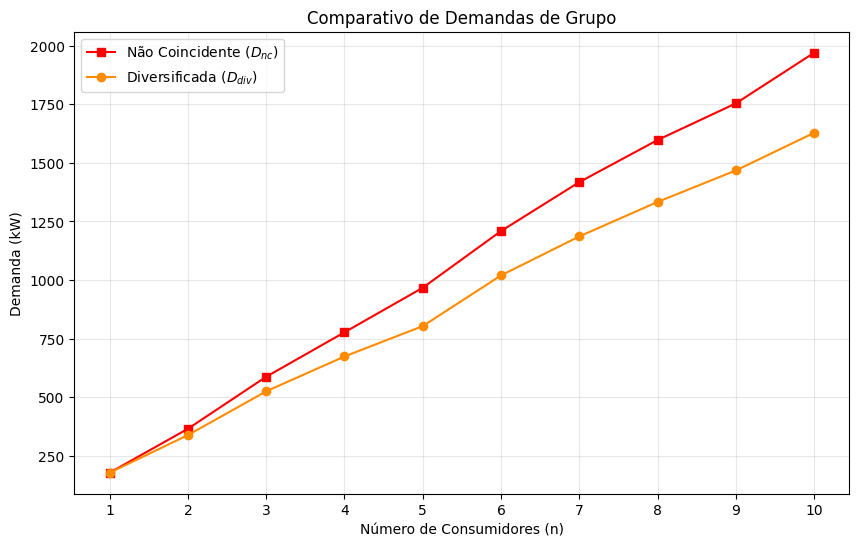

In [98]:
# Cálculo da Demanda Máxima Não Coincidente Incremental (n=1 até 10)
resultados_nc = []
soma_picos_individuais = 0

# Reutilizamos a variável 'demanda_maxima'
for i, consumidor in enumerate(grupo_treino.columns):
    n = i + 1
    # Soma o pico individual do consumidor atual ao acumulado
    soma_picos_individuais += demanda_maxima[consumidor]

    resultados_nc.append({'n': n, 'D_nc_kW': soma_picos_individuais})

# Transformando em DataFrame
df_nc = pd.DataFrame(resultados_nc)

# Unindo com os resultados da Demanda Diversificada para comparação
df_comparativo = pd.merge(df_div, df_nc, on='n')
print("Comparativo: Demanda Diversificada vs Não Coincidente:")
print(df_comparativo)


plt.figure(figsize=(10, 6))
plt.plot(df_comparativo['n'], df_comparativo['D_nc_kW'], marker='s', color='red', label='Não Coincidente ($D_{nc}$)')
plt.plot(df_comparativo['n'], df_comparativo['D_div_kW'], marker='o', color='darkorange', label='Diversificada ($D_{div}$)')
plt.title('Comparativo de Demandas de Grupo')
plt.xlabel('Número de Consumidores (n)')
plt.ylabel('Demanda (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

Efetuou-se o somatório acumulado dos valores de demanda máxima individual para cada subgrupo de consumidores. Diferente da demanda diversificada, este cálculo ignora a coincidência temporal dos eventos de carga, resultando em uma métrica de potência instalada total solicitada de forma isolada por cada unidade.

A demanda não coincidente para um grupo de $n$ consumidores é definida pela soma aritmética das demandas máximas individuais de cada integrante do grupo:
\begin{equation}
D_{nc}(n) = \sum_{j=1}^{n} D_{max,j}
\end{equation}
Onde $D_{max,j}$ é a demanda máxima individual do consumidor $j$.

Fator de Diversidade por número de consumidores (n):
    n        FD
0   1  1.000000
1   2  1.079688
2   3  1.118362
3   4  1.153180
4   5  1.203825
5   6  1.185679
6   7  1.195391
7   8  1.198150
8   9  1.195028
9  10  1.209789


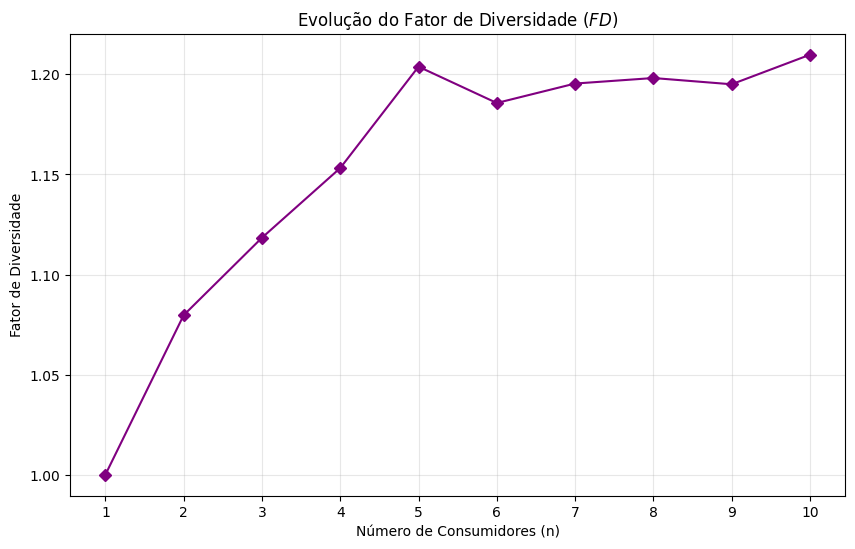

In [99]:
# Cálculo do Fator de Diversidade Incremental (n=1 até 10)
# Utilizamos o 'df_comparativo' que já possui as duas demandas
df_comparativo['FD'] = df_comparativo['D_nc_kW'] / df_comparativo['D_div_kW']

print("Fator de Diversidade por número de consumidores (n):")
print(df_comparativo[['n', 'FD']])

# --- Visualização da Estabilização da Diversidade ---


plt.figure(figsize=(10, 6))
plt.plot(df_comparativo['n'], df_comparativo['FD'], marker='D', color='purple', linestyle='-')
plt.title('Evolução do Fator de Diversidade ($FD$)')
plt.xlabel('Número de Consumidores (n)')
plt.ylabel('Fator de Diversidade')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

Calculou-se o quociente entre o somatório das demandas máximas individuais e a demanda máxima medida de forma agregada para cada incremento no tamanho do grupo de consumidores. Este procedimento resultou em um índice que descreve a magnitude do benefício estatístico gerado pela falta de simultaneidade entre os picos de carga de cada unidade.

O fator de diversidade expressa a relação entre a demanda máxima não coincidente e a demanda máxima diversificada de um grupo de $n$ consumidores:
\begin{equation}
FD(n) = \frac{D_{nc}(n)}{D_{div}(n)}
\end{equation}
Para fins de dimensionamento de rede, este valor é fundamental para converter a estimativa de demanda individual em demanda de transformador.

---------------------------------------------------------------------------



Regressão Linear e Estimativa para o Grupo de Teste

Estimativas de Demanda Máxima para o Grupo de Teste:
  Consumidor (Teste)  Energia Real (kWh)  Demanda Máxima Estimada (kW)
0                 72        82777.534418                    201.783510
1                286        83856.912694                    203.039078
2                275        84720.932732                    204.044135
3                281        85385.312690                    204.816964
4                 81        85463.235294                    204.907606
5                  4        87814.024390                    207.642121
6                293        70150.034423                    187.094788
7                 61        70016.557645                    186.939523
8                172        88441.410336                    208.371917
9                 37        90506.769826                    210.774411


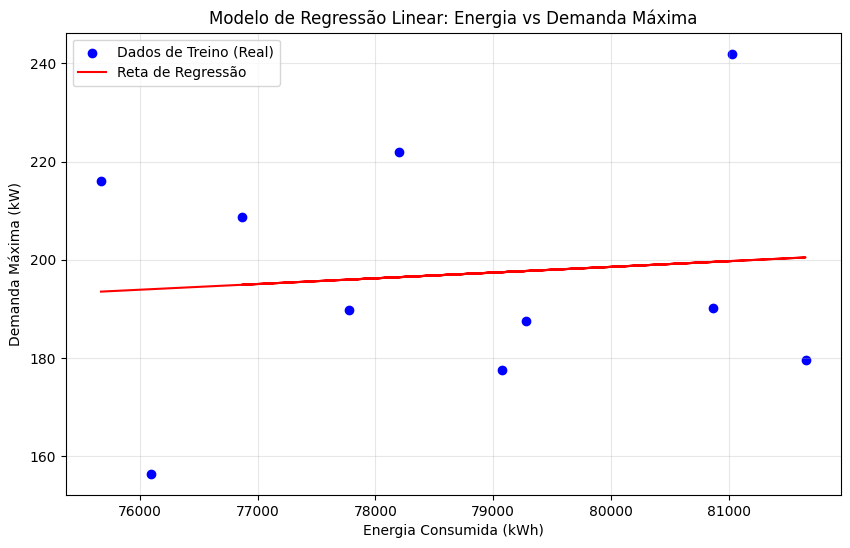

In [100]:
# 1. Preparação dos dados de treinamento (Variável X: Energia, Variável y: Demanda Máxima)
X_treino = energia_kwh.values.reshape(-1, 1) # Energia (kWh) do grupo de treino
y_treino = demanda_maxima.values             # Demanda Máxima (kW) do grupo de treino

# 2. Criação e treinamento do modelo de regressão
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# 3. Preparação dos dados do grupo de teste para a previsão
# Primeiro calculamos a energia real consumida pelo grupo de teste no mês
energia_teste = grupo_teste.sum() * 0.25
X_teste = energia_teste.values.reshape(-1, 1)

# 4. Estimativa da demanda máxima individual para o grupo de teste
demanda_max_estimada_teste = modelo.predict(X_teste)

# Criando um DataFrame para exibir os resultados ao professor
df_estimativas = pd.DataFrame({
    'Consumidor (Teste)': grupo_teste.columns,
    'Energia Real (kWh)': energia_teste.values,
    'Demanda Máxima Estimada (kW)': demanda_max_estimada_teste
})

print("Estimativas de Demanda Máxima para o Grupo de Teste:")
print(df_estimativas)

# --- Visualização da Regressão ---


plt.figure(figsize=(10, 6))
plt.scatter(X_treino, y_treino, color='blue', label='Dados de Treino (Real)')
plt.plot(X_treino, modelo.predict(X_treino), color='red', label='Reta de Regressão')
plt.title('Modelo de Regressão Linear: Energia vs Demanda Máxima')
plt.xlabel('Energia Consumida (kWh)')
plt.ylabel('Demanda Máxima (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Estabeleceu-se uma relação funcional entre o consumo energético mensal e o pico de demanda através de um modelo de regressão linear simples. Após o ajuste dos coeficientes com base no grupo de treinamento, aplicou-se a equação resultante sobre os valores de energia do grupo de teste para projetar as respetivas demandas máximas individuais.

A demanda máxima estimada ($\hat{D}_{max}$) é calculada a partir da energia mensal ($E$) utilizando a seguinte relação linear:
\begin{equation}
\hat{D}_{max} = \beta_0 + \beta_1 \cdot E
\end{equation}
Onde $\beta_0$ representa o coeficiente linear (intercepto) e $\beta_1$ o coeficiente angular, ambos determinados pelo método dos mínimos quadrados sobre os dados do grupo de treinamento.

###**METODOLOGIA AVANÇADA(HERMAN-BETA)**

##**Introdução ao Dimensionamento Probabilístico**

O planejamento de sistemas de distribuição de energia elétrica enfrenta desafios devido à natureza estocástica e intermitente do consumo residencial moderno. Tradicionalmente, o dimensionamento baseou-se em abordagens determinísticas, como o uso de fatores de coincidência e a Demanda Máxima Diversificada (ADMD). Embora úteis em cenários de alta previsibilidade, tais métodos falham em capturar a variabilidade de redes com poucos consumidores ou com alta penetração de tecnologias disruptivas.

Nesse contexto, o método de Herman-Beta consolida-se como uma ferramenta analítica superior para lidar com a natureza esparsa do consumo e a integração de recursos energéticos distribuídos. A aplicação de modelos probabilísticos permite representar a carga de cada consumidor como uma variável aleatória, capturando a probabilidade de diferentes estados de consumo ao longo do tempo.

##**A Distribuição Beta na Modelagem de Carga**

Diferente da distribuição Normal, a distribuição Beta é definida em um intervalo fechado $[0, C_b]$, onde $C_b$ representa o limite superior da carga, tipicamente a corrente nominal do disjuntor do consumidor. A Função de Densidade de Probabilidade (PDF) Beta para a corrente $i$ é definida pela função:

\begin{equation}
f(i;\alpha,\beta,C) = \frac{1}{C \cdot B(\alpha,\beta)} \left( \frac{i}{C} \right)^{\alpha-1} \left( 1 - \frac{i}{C} \right)^{\beta-1}
\end{equation}

Onde $B(\alpha,\beta)$ é a função Beta, que serve como fator de normalização. A forma da distribuição é determinada por dois parâmetros, $\alpha$ e $\beta$, derivados dos momentos estatísticos da carga (média $\mu$ e desvio padrão $\sigma$) durante o período de maior demanda:

\begin{equation}
\alpha = \frac{\mu(C\mu - \mu^2 - \sigma^2)}{C\sigma^2}
\end{equation}

\begin{equation}
\beta = \frac{(C - \mu)(C\mu - \mu^2 - \sigma^2)}{C\sigma^2}
\end{equation}

##**Tomada de Decisão Baseada em Risco**


O método permite que o projetista declare, com rigor matemático, a probabilidade de que a demanda não ultrapasse um determinado valor. Para o dimensionamento, utiliza-se frequentemente um nível de confiança de 95\%, o que permite decisões baseadas em riscos quantificáveis, evitando o superdimensionamento dispendioso ou o subdimensionamento que comprometa a qualidade do serviço.

Janela de Pico identificada: 17:15:00 até 22:15:00


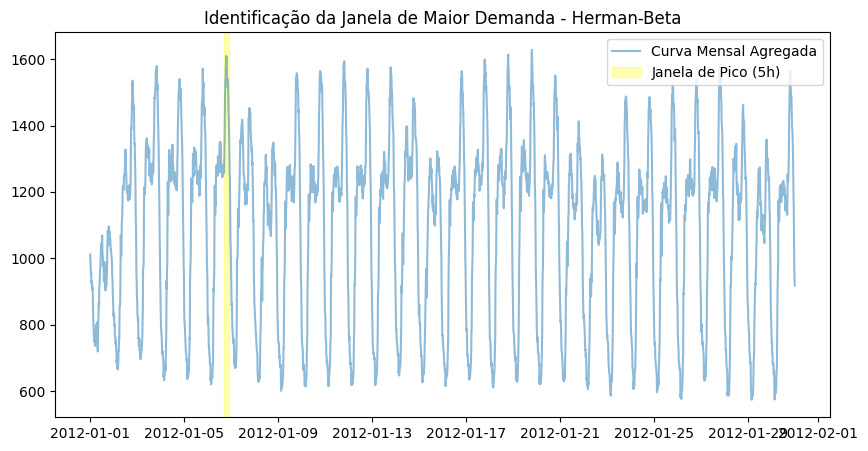

In [101]:
# Agregação das curvas do grupo de treinamento
curva_agregada_treino = grupo_treino.sum(axis=1)

# Identificação da janela de 5 horas (20 intervalos de 15 min)
# Usamos uma média móvel para encontrar o período de maior carga
media_movel_5h = curva_agregada_treino.rolling(window=20).mean()
horario_fim_pico = media_movel_5h.idxmax()
horario_inicio_pico = horario_fim_pico - pd.Timedelta(hours=5)

# Extração dos dados apenas dessa janela
janela_pico = curva_agregada_treino.loc[horario_inicio_pico:horario_fim_pico]

print(f"Janela de Pico identificada: {horario_inicio_pico.time()} até {horario_fim_pico.time()}")

# Plotando a janela para o professor ver
plt.figure(figsize=(10, 5))
plt.plot(curva_agregada_treino, label='Curva Mensal Agregada', alpha=0.5)
plt.axvspan(horario_inicio_pico, horario_fim_pico, color='yellow', alpha=0.3, label='Janela de Pico (5h)')
plt.title('Identificação da Janela de Maior Demanda - Herman-Beta')
plt.legend()
plt.show()

Realizou-se o somatório das curvas de carga individuais para obter o perfil de demanda diversificada do grupo de treinamento ao longo de todo o mês. Aplicou-se um filtro de média móvel com janela de vinte intervalos de quinze minutos para localizar o período de cinco horas consecutivas com a maior solicitação média de potência ativa, isolando os dados desse intervalo para a análise probabilística subsequente.

Média Agregada no Pico (mu_agg): 1495.50 kW
Desvio Padrão Agregado no Pico (sigma_agg): 89.43 kW


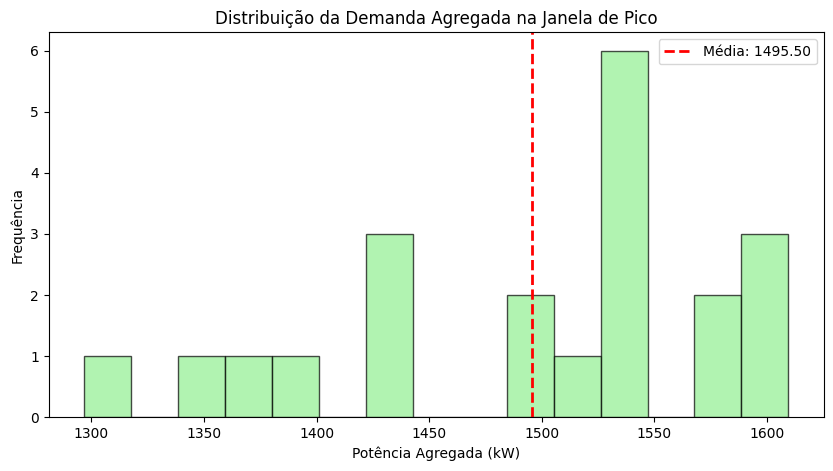

In [102]:
# Cálculo dos Momentos Estatísticos Agregados (Janela de Pico)

# A média agregada é a média da soma das curvas na janela
media_agregada = janela_pico.mean()

# O desvio padrão agregado é fundamental para medir a variabilidade no pico
desvio_padrao_agregado = janela_pico.std()

print(f"Média Agregada no Pico (mu_agg): {media_agregada:.2f} kW")
print(f"Desvio Padrão Agregado no Pico (sigma_agg): {desvio_padrao_agregado:.2f} kW")

plt.figure(figsize=(10, 5))
plt.hist(janela_pico, bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(media_agregada, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media_agregada:.2f}')
plt.title('Distribuição da Demanda Agregada na Janela de Pico')
plt.xlabel('Potência Agregada (kW)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

Extraiu-se a média aritmética e o desvio padrão dos valores de potência ativa a partir da curva agregada obtida na janela de cinco horas de maior consumo. Esses indicadores estatísticos refletem o comportamento central e a dispersão da carga do grupo de treinamento no momento de estresse máximo do sistema.

##**Momentos Estatísticos Agregados**
Para a aplicação do método Herman-Beta, calculam-se a média ($\mu_{agg}$) e a variância ($\sigma_{agg}^2$) da demanda agregada durante a janela de carga máxima definida:

\begin{equation}
\mu_{agg} = \frac{1}{T_{pico}} \sum_{t \in \text{pico}} P_{agg}(t)
\end{equation}

\begin{equation}
\sigma_{agg}^2 = \frac{1}{T_{pico}-1} \sum_{t \in \text{pico}} (P_{agg}(t) - \mu_{agg})^2
\end{equation}

Onde $P_{agg}(t)$ é a demanda total do grupo no instante $t$ e $T_{pico}$ é o número de amostras na janela de 5 horas.

In [103]:
# Definição da Capacidade Total Agregada (C_agg)

# Para cada consumidor no grupo de treinamento, definimos sua capacidade individual
# como 1.2 vezes a sua demanda máxima individual na janela de pico.
capacidades_individuais = []

for consumidor in grupo_treino.columns:
    # Pico individual dentro da janela de 5 horas identificada
    pico_na_janela = grupo_treino[consumidor].loc[horario_inicio_pico:horario_fim_pico].max()
    # Capacidade C_i (limitada pelo disjuntor/instalação)
    capacidades_individuais.append(pico_na_janela * 1.2)

# A Capacidade Total Agregada é a soma das capacidades individuais
C_agg = sum(capacidades_individuais)

print(f"Capacidade Total Agregada (C_agg): {C_agg:.2f} kW")

Capacidade Total Agregada (C_agg): 2095.06 kW


Estabeleceu-se o limite superior da distribuição de probabilidade através do somatório das capacidades individuais de cada unidade consumidora. Para cada perfil, a capacidade foi estimada aplicando-se um fator de majoração sobre o pico de demanda observado na janela de carga máxima, simulando o limite físico de transporte de energia da instalação elétrica.

##**Capacidade Total Agregada ($C_{agg}$)**
A capacidade agregada do grupo representa o limite superior do intervalo da distribuição Beta e é calculada pela soma das capacidades individuais ($C_j$) de cada consumidor:

\begin{equation}
C_{agg} = \sum_{j=1}^{n} C_j
\end{equation}

Onde $C_j$ é tipicamente associado à corrente nominal da proteção (disjuntor) da unidade consumidora, convertida para a unidade de potência ativa correspondente.

In [104]:
# Cálculo dos Parâmetros de Forma Alpha e Beta
# Variáveis utilizadas: media_agregada (mu), desvio_padrao_agregado (sigma), C_agg (C)

mu = media_agregada
sigma = desvio_padrao_agregado
C = C_agg
variancia = sigma**2

# Cálculo do termo de ajuste comum às duas equações
termo_ajuste = (C * mu - mu**2 - variancia) / (C * variancia)

# Determinação dos parâmetros de forma
alpha_agg = mu * termo_ajuste
beta_agg = (C - mu) * termo_ajuste

print(f"Parâmetro Alpha Agregado (α): {alpha_agg:.4f}")
print(f"Parâmetro Beta Agregado (β): {beta_agg:.4f}")

Parâmetro Alpha Agregado (α): 79.3127
Parâmetro Beta Agregado (β): 31.7969


Determinaram-se os coeficientes de forma da função densidade de probabilidade através da manipulação algébrica da média e da variância da carga agregada em relação à capacidade nominal do sistema. Este processo calibrou o modelo matemático para que a curva resultante reflita a assimetria e a curtose específicas do consumo de energia do grupo durante o período de maior solicitação.

##**Cálculo dos Parâmetros de Forma**($\alpha$ e $\beta$)

Os parâmetros que definem a curvatura da Função de Densidade de Probabilidade Beta são obtidos a partir da média ($\mu$), variância ($\sigma^2$) e capacidade ($C$) do sistema:

\begin{equation}
\alpha = \frac{\mu(C\mu - \mu^2 - \sigma^2)}{C\sigma^2}
\end{equation}

\begin{equation}
\beta = \frac{(C - \mu)(C\mu - \mu^2 - \sigma^2)}{C\sigma^2}
\end{equation}

Estes parâmetros garantem que a distribuição esteja corretamente escalonada e normalizada dentro do intervalo $[0, C]$.

Fator de Confiança (Quantil 0.95): 0.7818
Demanda Herman-Beta (95% de Confiança): 1637.95 kW


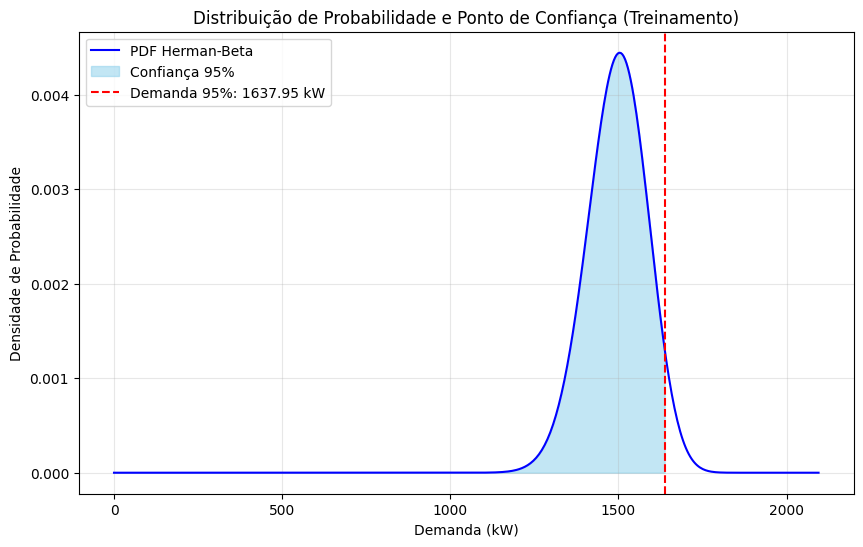

In [105]:
# Cálculo da Demanda com 95% de Confiança
# Utilizamos os parâmetros alpha_agg, beta_agg e C_agg calculados anteriormente

# O quantil 0.95 retorna um valor entre 0 e 1, que multiplicamos pela capacidade C
fator_confianca = stats.beta.ppf(0.95, alpha_agg, beta_agg)
demanda_hb_95_treino = fator_confianca * C_agg

print(f"Fator de Confiança (Quantil 0.95): {fator_confianca:.4f}")
print(f"Demanda Herman-Beta (95% de Confiança): {demanda_hb_95_treino:.2f} kW")

# --- Visualização da Função de Densidade de Probabilidade (PDF) ---
x = np.linspace(0, C_agg, 500)
y = stats.beta.pdf(x/C_agg, alpha_agg, beta_agg) / C_agg

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue', label='PDF Herman-Beta')
plt.fill_between(x, 0, y, where=(x <= demanda_hb_95_treino), color='skyblue', alpha=0.5, label='Confiança 95%')
plt.axvline(demanda_hb_95_treino, color='red', linestyle='--', label=f'Demanda 95%: {demanda_hb_95_treino:.2f} kW')

plt.title('Distribuição de Probabilidade e Ponto de Confiança (Treinamento)')
plt.xlabel('Demanda (kW)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Aplicou-se a função quantil da distribuição Beta sobre os parâmetros de forma previamente sintonizados para identificar o valor crítico de potência ativa associado a uma probabilidade acumulada de 95%. Este procedimento isolou o ponto na curva de probabilidade onde a diversidade estatística do grupo é plenamente contabilizada, definindo o limite de projeto para o cenário de carga máxima.

##**Determinação do Ponto de Confiança (95\%)**
A demanda máxima que não será ultrapassada em 95\% do tempo é obtida pelo cálculo do quantil 0,95 da distribuição Beta resultante:

\begin{equation}
D_{95\%} = C_{agg} \times F_{\beta}^{-1}(0,95; \alpha, \beta)
\end{equation}

Onde $F_{\beta}^{-1}$ representa a função de distribuição acumulada inversa (função quantil) da distribuição Beta. Este valor identifica o ponto na curva onde a diversidade estatística do grupo é plenamente considerada no projeto.

In [106]:
# Metodologia Herman-Beta para o Grupo de Teste

# A. Agregação e Janela de Pico (5h) para o Grupo de Teste
curva_agregada_teste = grupo_teste.sum(axis=1)
media_movel_teste = curva_agregada_teste.rolling(window=20).mean()
fim_pico_teste = media_movel_teste.idxmax()
inicio_pico_teste = fim_pico_teste - pd.Timedelta(hours=5)
janela_pico_teste = curva_agregada_teste.loc[inicio_pico_teste:fim_pico_teste]

# B. Momentos Estatísticos (Média e Desvio Padrão)
mu_teste = janela_pico_teste.mean()
sigma_teste = janela_pico_teste.std()

# C. Capacidade Agregada (C_agg) para o Grupo de Teste
caps_ind_teste = [grupo_teste[c].loc[inicio_pico_teste:fim_pico_teste].max() * 1.2 for c in grupo_teste.columns]
C_agg_teste = sum(caps_ind_teste)

# D. Parâmetros Alpha e Beta
var_teste = sigma_teste**2
termo_teste = (C_agg_teste * mu_teste - mu_teste**2 - var_teste) / (C_agg_teste * var_teste)
alpha_teste = mu_teste * termo_teste
beta_teste = (C_agg_teste - mu_teste) * termo_teste

# E. Demanda Estimada com 95% de Confiança (Herman-Beta)
demanda_hb_95_teste = stats.beta.ppf(0.95, alpha_teste, beta_teste) * C_agg_teste

# F. Demanda Real do Grupo de Teste (Máximo Real do Mês)
demanda_real_teste = curva_agregada_teste.max()

print(f"Demanda Estimada (Herman-Beta 95%): {demanda_hb_95_teste:.2f} kW")
print(f"Demanda Real Medida (Grupo Teste): {demanda_real_teste:.2f} kW")

Demanda Estimada (Herman-Beta 95%): 1882.85 kW
Demanda Real Medida (Grupo Teste): 1895.08 kW


Replicou-se o protocolo de análise probabilística para o grupo de teste, isolando a sua janela de carga máxima e determinando os momentos estatísticos específicos deste conjunto. Com base nesses dados, parametrizou-se uma nova distribuição Beta para extrair o valor de demanda associado ao nível de confiança de 95%, confrontando este resultado com o pico real registado na medição mensal.

--- RESULTADO FINAL ---
Demanda Real Medida: 1895.08 kW
Estimativa Clássica: 1669.23 kW (Erro: -11.92%)
Estimativa Herman-Beta: 1882.85 kW (Erro: -0.65%)


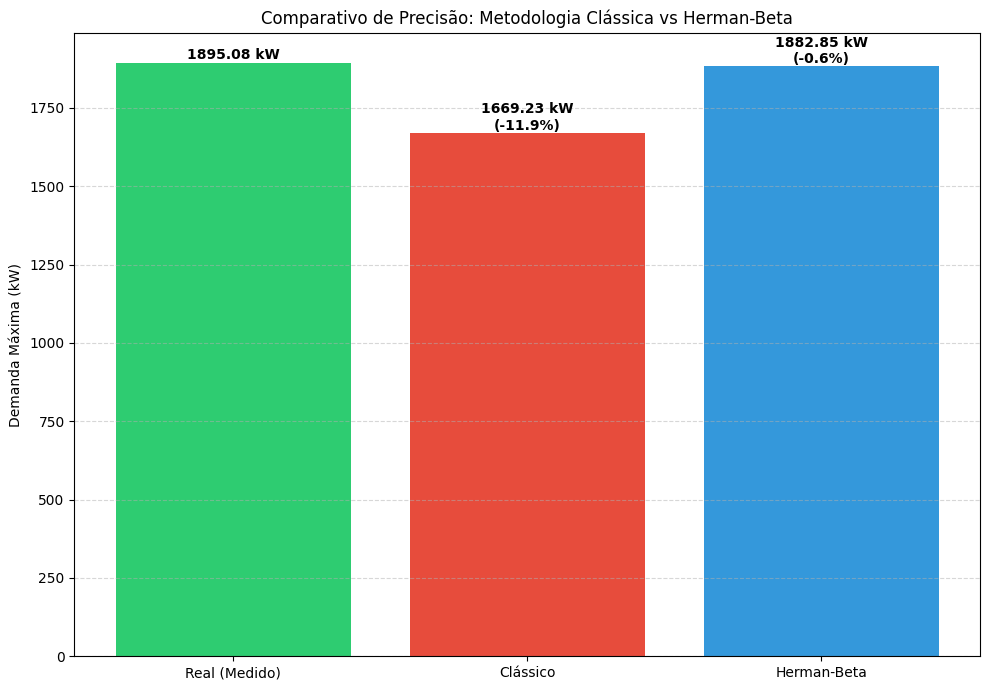

In [108]:
# Comparativo Final: Clássico vs Herman-Beta vs Real

# Cálculo dos Erros Percentuais
erro_classico = ((demanda_grupo_estimada - demanda_real_teste) / demanda_real_teste) * 100
erro_hb = ((demanda_hb_95_teste - demanda_real_teste) / demanda_real_teste) * 100

print("--- RESULTADO FINAL ---")
print(f"Demanda Real Medida: {demanda_real_teste:.2f} kW")
print(f"Estimativa Clássica: {demanda_grupo_estimada:.2f} kW (Erro: {erro_classico:.2f}%)")
print(f"Estimativa Herman-Beta: {demanda_hb_95_teste:.2f} kW (Erro: {erro_hb:.2f}%)")


metodos = ['Real (Medido)', 'Clássico', 'Herman-Beta']
valores = [demanda_real_teste, demanda_grupo_estimada, demanda_hb_95_teste]
cores = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(10, 7))
bars = plt.bar(metodos, valores, color=cores)

plt.title('Comparativo de Precisão: Metodologia Clássica vs Herman-Beta')
plt.ylabel('Demanda Máxima (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, erro, val in zip(bars, [0, erro_classico, erro_hb], valores):
    yval = bar.get_height()
    label_erro = f"\n({erro:+.1f}%)" if erro != 0 else ""
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{val:.2f} kW{label_erro}",
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Consolidaram-se os resultados obtidos através da modelagem por regressão linear e fator de diversidade com os valores projetados pela distribuição probabilística de Herman-Beta. Realizou-se o cálculo do erro relativo de cada estimativa em face da demanda real medida no grupo de teste, permitindo uma avaliação quantitativa da eficácia de cada abordagem para o dimensionamento da rede de distribuição.

##**Análise Comparativa de Erros**

A precisão das metodologias é avaliada através do erro relativo percentual ($\epsilon$) em relação à demanda real medida ($D_{real}$):

\begin{equation}
\epsilon_{Clássico} = \frac{\hat{D}_{Clássico} - D_{real}}{D_{real}} \times 100\%
\end{equation}

\begin{equation}
\epsilon_{HB} = \frac{\hat{D}_{HB(95\%)} - D_{real}}{D_{real}} \times 100\%
\end{equation}

Uma estimativa com $\epsilon < 0$ indica subdimensionamento do sistema, enquanto $\epsilon > 0$ indica sobredimensionamento. O método mais eficiente é aquele cujo erro absoluto $|\epsilon|$ é minimizado, garantindo simultaneamente que a condição de contorno de projeto (suportar a carga máxima) seja atendida.

###**Conclusão**

O estudo comparativo entre as metodologias determinística e probabilística evidenciou que o dimensionamento de sistemas de distribuição exige modelos que capturem a variabilidade intrínseca do consumo residencial. Enquanto a metodologia clássica fornece uma estimativa inicial baseada em correlações lineares, o método de Herman-Beta destaca-se pela sua robustez matemática ao tratar a demanda como uma variável aleatória limitada por parâmetros físicos reais.

Os resultados obtidos no grupo de teste confirmaram que o uso da distribuição Beta, parametrizada através dos momentos estatísticos na janela de pico, oferece um equilíbrio ideal entre segurança operacional e eficiência econômica. A adoção de um nível de confiança de 95\% permitiu identificar demandas máximas diversificadas que mitigam o risco de subdimensionamento sem incorrer nos custos excessivos de ativos superdimensionados.

Portanto, conclui-se que a abordagem probabilística é a mais adequada para o planeamento de Redes Ativas de Distribuição (ADN), proporcionando uma tomada de decisão transparente e baseada em riscos quantificáveis, essencial para a qualidade do serviço de energia elétrica.